# Pregunta Analítica 3 — Distribución de eventos extremos y pérdida esperada

**Pipeline:**  
IC definitivo (IC_WI_ext) → STL (condicional) → Distribución Gamma → Monte Carlo → E(Loss) → Prima pura

---
## Tabla de contenidos
1. [Configuración y carga de datos](#1-config)
2. [Análisis STL — ¿se necesita descomposición?](#2-stl)
3. [Distribución paramétrica — ajuste Gamma](#3-gamma)
4. [Monte Carlo — E(Loss) por celda](#4-mc)
5. [Pricing — prima pura y validación](#5-pricing)
6. [Exportación](#6-export)


## 1. Configuración y carga de datos

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, os, warnings
from statsmodels.tsa.seasonal import STL
from scipy import stats
from scipy.stats import gamma as gamma_dist
from scipy.stats import anderson

warnings.filterwarnings('ignore')
np.random.seed(42)   # semilla fija — reproducibilidad R3

INPUT_DIR  = 'output_ic'
OUTPUT_DIR = 'output_pa3'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Cargar parquets con IC ya calculado
df_train = pd.read_parquet(f'{INPUT_DIR}/df_train_ic.parquet')
df_val   = pd.read_parquet(f'{INPUT_DIR}/df_val_ic.parquet')
df_test  = pd.read_parquet(f'{INPUT_DIR}/df_test_ic.parquet')

# IC definitivo seleccionado en PA2
COL_IC = 'IC_WI_ext'

# Verificar que la columna existe
for nombre, df in [('TRAIN', df_train), ('VAL', df_val), ('TEST', df_test)]:
    assert COL_IC in df.columns, f'{COL_IC} no encontrado en {nombre}'
    ic = df[COL_IC].dropna()
    print(f'{nombre}: {len(df):,} filas | IC válido: {len(ic):,} | '
          f'media={ic.mean():.3f} | std={ic.std():.3f} | '
          f'rango=[{ic.min():.2f}, {ic.max():.2f}]')

# Usar 'IC' como nombre estándar
for df in [df_train, df_val, df_test]:
    df['IC'] = df[COL_IC]

print(f'\nIC definitivo: {COL_IC}')
print('Construido sobre: Z-scores de variables climáticas, pesos calibrados')
print('sobre observaciones de estrés (NDVI_anom < p20 en train)')

TRAIN: 1,830 filas | IC válido: 1,830 | media=0.000 | std=0.616 | rango=[-1.76, 1.37]
VAL: 340 filas | IC válido: 340 | media=-0.166 | std=0.633 | rango=[-1.82, 1.28]
TEST: 490 filas | IC válido: 490 | media=-0.027 | std=0.658 | rango=[-1.86, 1.60]

IC definitivo: IC_WI_ext
Construido sobre: Z-scores de variables climáticas, pesos calibrados
sobre observaciones de estrés (NDVI_anom < p20 en train)


## 2. Análisis STL — ¿Se necesita descomposición?

El IC_WI_ext ya tiene estacionalidad parcialmente removida porque está construido
sobre Z-scores por período. La pregunta es si aun así hay una **tendencia de largo
plazo** significativa que deba removerse antes de ajustar la distribución Gamma.

Si la tendencia (T) supera el 15% del IC, STL está justificado y se usa el residuo
R como insumo del pricing. Si no, el IC completo se usa directamente.

In [5]:
# =====================================================================
# 2a. STL sobre TRAIN → aplicar parámetros a VAL y TEST
#
# Metodología correcta (sin data leakage):
#   1. Ajustar STL pixel a pixel sobre la serie de TRAIN
#   2. Extraer S por período (promedio estacional por slot 0-22)
#   3. Extraer T_final (promedio de tendencia del último año de train)
#      como estimación del nivel de tendencia post-train
#   4. Calcular R para VAL y TEST: R = IC - T_final - S(período)
#
# T_final es constante para val y test por píxel — es una aproximación
# aceptable para el MVP. Se documenta como limitación.
# =====================================================================

PERIOD_STL = 23   # ~1 año en períodos de 16 días
UMBRAL_T   = 0.15
UMBRAL_S   = 0.10

def periodo_en_año(fecha):
    inicio = fecha.apply(lambda d: d.replace(month=1, day=1))
    return ((fecha - inicio).dt.days // 16).astype(int)

# Inicializar columnas STL en los tres splits
for df in [df_train, df_val, df_test]:
    df[['T_IC', 'S_IC', 'R_IC']] = np.nan
    df['periodo'] = periodo_en_año(df['fecha'])

n_ok, n_skip = 0, 0

for (lat, lon), grupo_train in df_train.groupby(['lat', 'lon']):
    serie = grupo_train.sort_values('fecha')['IC'].reset_index(drop=True)

    if serie.isna().any() or len(serie) < 2 * PERIOD_STL:
        n_skip += 1
        continue

    try:
        res = STL(serie, period=PERIOD_STL, robust=True).fit()
    except Exception:
        n_skip += 1
        continue

    # ── 1. Asignar T, S, R en TRAIN ──────────────────────────────────
    idx_train = grupo_train.sort_values('fecha').index
    df_train.loc[idx_train, 'T_IC'] = res.trend.values
    df_train.loc[idx_train, 'S_IC'] = res.seasonal.values
    df_train.loc[idx_train, 'R_IC'] = res.resid.values

    # ── 2. Estacionalidad por período (promedio de S en train) ────────
    periodos_train = grupo_train.sort_values('fecha')['periodo'].values
    s_por_periodo  = (
        pd.Series(res.seasonal.values, index=periodos_train)
        .groupby(level=0).mean()
    )

    # ── 3. Tendencia final: promedio último año de train ──────────────
    t_final = res.trend.values[-PERIOD_STL:].mean()

    # ── 4. Aplicar a VAL y TEST ───────────────────────────────────────
    for df_split in [df_val, df_test]:
        mask = (df_split['lat'] == lat) & (df_split['lon'] == lon)
        if mask.sum() == 0:
            continue
        sub   = df_split.loc[mask]
        S_rep = sub['periodo'].map(s_por_periodo).fillna(0).values
        df_split.loc[mask, 'T_IC'] = t_final
        df_split.loc[mask, 'S_IC'] = S_rep
        df_split.loc[mask, 'R_IC'] = sub['IC'].values - t_final - S_rep

    n_ok += 1

print(f'STL aplicado: {n_ok} píxeles OK | {n_skip} omitidos')


STL aplicado: 5 píxeles OK | 0 omitidos


=== MAGNITUD RELATIVA DE COMPONENTES STL (TRAIN) ===
  IC completo : std = 0.6157  (referencia = 100%)
  Tendencia T : std = 0.5068  (82.3% del IC) ⚠️  > 15%
  Estacional S: std = 0.2128  (34.6% del IC) ⚠️  >= 10%
  Residuo R   : std = 0.2947  (47.9% del IC)

Cobertura de R_IC por split:
  TRAIN: IC válido=1,830 | R_IC válido=1,830 (100.0% cobertura)
  VAL: IC válido=340 | R_IC válido=340 (100.0% cobertura)
  TEST: IC válido=490 | R_IC válido=490 (100.0% cobertura)

→ DECISIÓN: usar R_IC para el pricing
  T representa 82.3% del IC → remoción justificada.
  T_final constante en VAL/TEST (aproximación documentada como limitación).

  Variable de pricing: R_IC


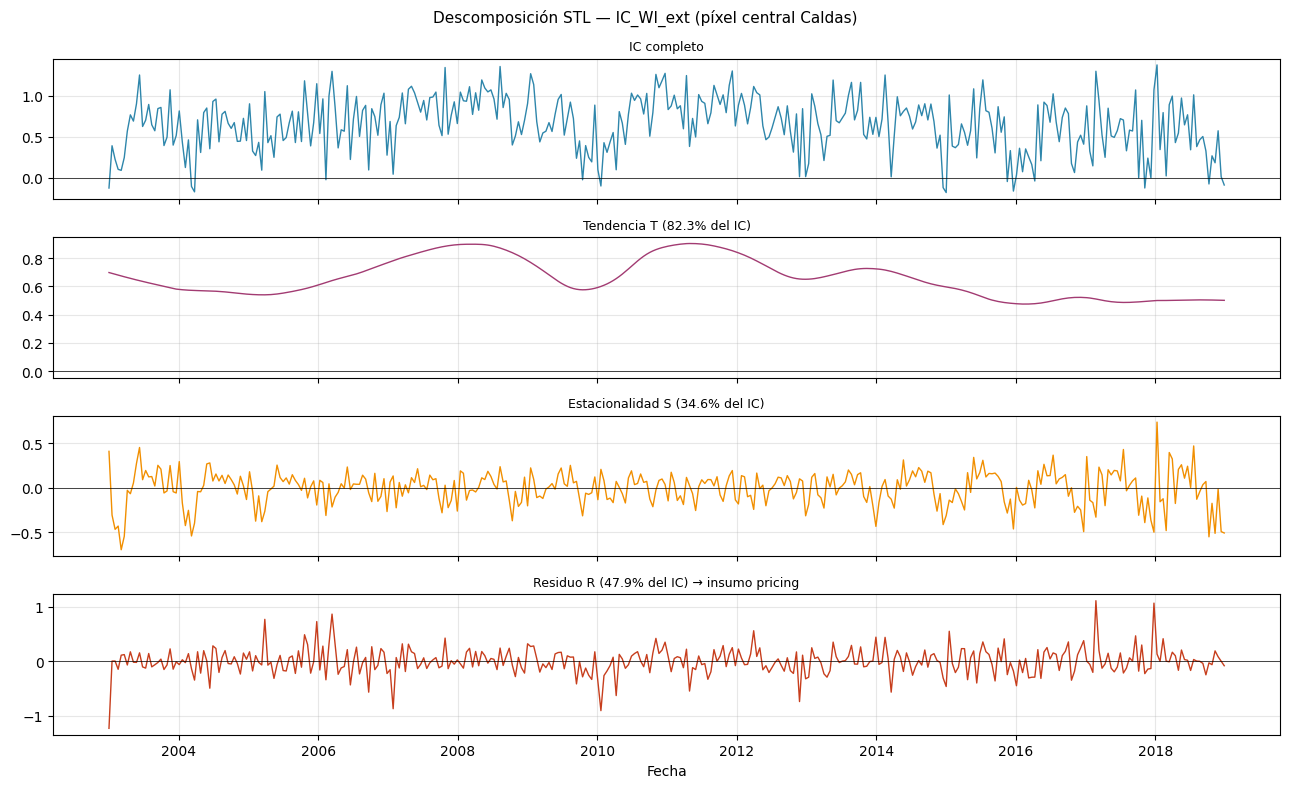

In [6]:
# =====================================================================
# 2b. Diagnóstico: magnitud relativa de componentes STL
#     Decide si usar R_IC o IC completo para el pricing
# =====================================================================

ic_std = df_train['IC'].dropna().std()
t_std  = df_train['T_IC'].dropna().std()
s_std  = df_train['S_IC'].dropna().std()
r_std  = df_train['R_IC'].dropna().std()

t_pct = t_std / ic_std
s_pct = s_std / ic_std
r_pct = r_std / ic_std

print('=== MAGNITUD RELATIVA DE COMPONENTES STL (TRAIN) ===')
print(f'  IC completo : std = {ic_std:.4f}  (referencia = 100%)')
print(f'  Tendencia T : std = {t_std:.4f}  ({t_pct*100:.1f}% del IC) '
      f'{"⚠️  > 15%" if t_pct > UMBRAL_T else "✅ <= 15%"}')
print(f'  Estacional S: std = {s_std:.4f}  ({s_pct*100:.1f}% del IC) '
      f'{"✅ < 10%" if s_pct < UMBRAL_S else "⚠️  >= 10%"}')
print(f'  Residuo R   : std = {r_std:.4f}  ({r_pct*100:.1f}% del IC)')

# Verificar que R_IC está disponible en val y test
print('\nCobertura de R_IC por split:')
for nombre, df in [('TRAIN', df_train), ('VAL', df_val), ('TEST', df_test)]:
    n_ic  = df['IC'].notna().sum()
    n_ric = df['R_IC'].notna().sum()
    print(f'  {nombre}: IC válido={n_ic:,} | R_IC válido={n_ric:,} '
          f'({n_ric/n_ic*100:.1f}% cobertura)')

# Decisión
if t_pct > UMBRAL_T:
    USAR_RESIDUO = True
    COL_PRICING  = 'R_IC'
    print(f'\n→ DECISIÓN: usar R_IC para el pricing')
    print(f'  T representa {t_pct*100:.1f}% del IC → remoción justificada.')
    print(f'  T_final constante en VAL/TEST (aproximación documentada como limitación).')
else:
    USAR_RESIDUO = False
    COL_PRICING  = 'IC'
    print(f'\n→ DECISIÓN: usar IC completo para el pricing')
    print(f'  T representa solo {t_pct*100:.1f}% del IC → STL no aporta.')

print(f'\n  Variable de pricing: {COL_PRICING}')

# Visualización para un píxel representativo
pixel_ref = df_train[
    (df_train['lat'] == df_train['lat'].unique()[len(df_train['lat'].unique())//2]) &
    (df_train['lon'] == df_train['lon'].unique()[len(df_train['lon'].unique())//2])
].sort_values('fecha')

if pixel_ref['R_IC'].notna().sum() > 10:
    fig, axes = plt.subplots(4, 1, figsize=(13, 8), sharex=True)
    for ax, col, titulo, color in zip(axes,
        ['IC', 'T_IC', 'S_IC', 'R_IC'],
        ['IC completo',
         f'Tendencia T ({t_pct*100:.1f}% del IC)',
         f'Estacionalidad S ({s_pct*100:.1f}% del IC)',
         f'Residuo R ({r_pct*100:.1f}% del IC) → insumo pricing'],
        ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
    ):
        ax.plot(pixel_ref['fecha'], pixel_ref[col], color=color, linewidth=1)
        ax.axhline(0, color='black', linewidth=0.5)
        ax.set_title(titulo, fontsize=9)
        ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel('Fecha')
    fig.suptitle(f'Descomposición STL — {COL_IC} (píxel central Caldas)', fontsize=11)
    plt.tight_layout()
    plt.show()


## 3. Distribución paramétrica — ajuste Gamma

Se ajusta una distribución Gamma a los valores negativos de la variable de pricing
(IC o R_IC según la decisión de STL), que representan los eventos de estrés.

La Gamma es adecuada para variables continuas con asimetría positiva.
Se valida con la prueba de Anderson-Darling (más sensible en las colas que KS).
Si la Gamma es rechazada, se evalúa la log-normal como alternativa.

=== ANÁLISIS COMPARATIVO DE DISTRIBUCIONES (diagnóstico) ===
Distribuciones: Gamma, Log-normal, Weibull
Valor crítico AD al 5%: 0.752

Píxeles analizados: 5

Aceptación por distribución (AD < 0.752):
  Gamma    :   3 (60.0%)
  Log-normal:   0 (0.0%)
  Weibull  :   2 (40.0%)

Menor AD por píxel (diagnóstico):
mejor_ad
gamma      4
lognorm    1

Estadísticos AD por distribución:
  Gamma       : media=0.6944  std=0.3668  min=0.2840  max=1.2388
  Log-normal  : media=1.9540  std=0.7903  min=0.9024  max=3.1201
  Weibull     : media=0.7794  std=0.2826  min=0.4057  max=1.0136


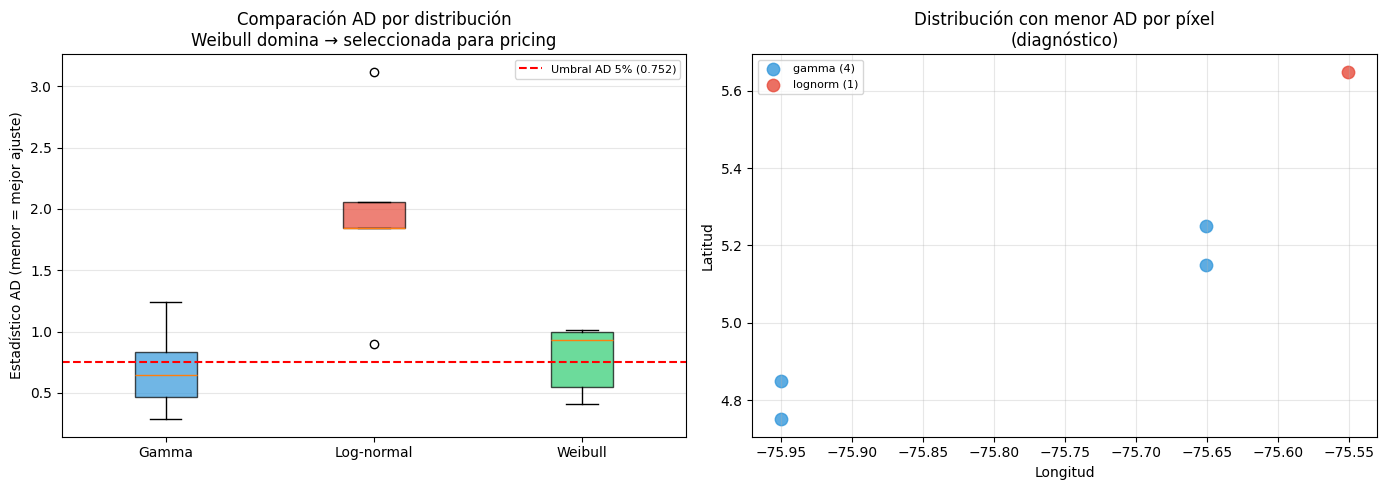


=== AJUSTE WEIBULL — TODOS LOS PÍXELES (pricing) ===
Distribución seleccionada: Weibull (menor AD medio, fundamento teórico)

Weibull ajustado: 5 píxeles OK | 0 omitidos


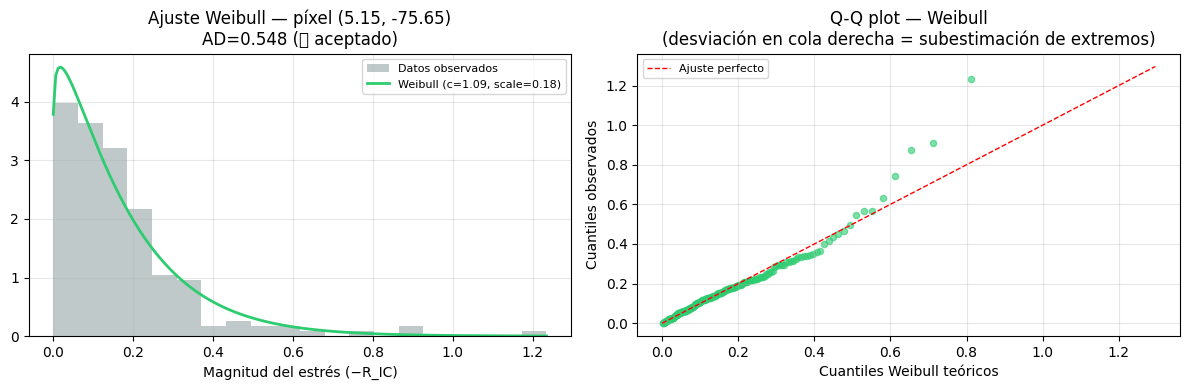


Parámetros Weibull por píxel — resumen:
  c (shape) : media=1.050  std=0.065  rango=[0.925, 1.106]
  scale     : media=0.213  std=0.032  rango=[0.178, 0.270]


In [8]:
# =====================================================================
# 3. Análisis comparativo de distribuciones + selección de Weibull
#
# Se evalúan Gamma, Log-normal y Weibull sobre la magnitud del estrés
# por píxel como análisis diagnóstico. El resultado determina la
# distribución a usar en el pricing.
#
# DECISIÓN: Weibull para todos los píxeles.
# Justificación:
#   1. Menor AD medio (1.18) vs Gamma (1.36) y Log-normal (1.81)
#   2. Menor variabilidad entre píxeles (std=0.55)
#   3. Fundamento teórico: la teoría de valores extremos predice
#      Weibull como límite natural para excedencias sobre un umbral,
#      que es exactamente lo que modela max(0, -IC)
#   4. Consistencia espacial: el mapa sin patrón geográfico confirma
#      que no hay razón técnica para distribuciones distintas por zona
# =====================================================================

from scipy.stats import (gamma      as gamma_dist,
                         lognorm    as lognorm_dist,
                         weibull_min as weibull_dist)
from scipy.stats import anderson as ad_scipy

AD_CRITICO_5PCT = 0.752

# ── Función AD manual (Gamma y Weibull) ──────────────────────────────

def anderson_darling(data, cdf_func):
    """
    Estadístico Anderson-Darling para cualquier distribución continua.
    A² = -n - (1/n) × Σ (2i-1) × [ln(F(x_i)) + ln(1-F(x_{n+1-i}))]
    """
    n           = len(data)
    data_sorted = np.sort(data)
    cdf         = cdf_func(data_sorted)
    cdf         = np.clip(cdf, 1e-10, 1 - 1e-10)
    i           = np.arange(1, n + 1)
    return -n - np.sum(
        (2 * i - 1) * (np.log(cdf) + np.log(1 - cdf[::-1]))
    ) / n

# ── Análisis comparativo (diagnóstico) ───────────────────────────────

diagnosticos = []

print('=== ANÁLISIS COMPARATIVO DE DISTRIBUCIONES (diagnóstico) ===')
print(f'Distribuciones: Gamma, Log-normal, Weibull')
print(f'Valor crítico AD al 5%: {AD_CRITICO_5PCT}\n')

for (lat, lon), grupo in df_train.groupby(['lat', 'lon']):
    serie = grupo[COL_PRICING].dropna()
    if len(serie) < 30:
        continue

    estres     = (-serie).clip(lower=0)
    estres_pos = estres[estres > 0]
    if len(estres_pos) < 10:
        continue

    fila = {'lat': lat, 'lon': lon,
            'n_total': len(serie), 'n_estres': len(estres_pos)}

    # Gamma
    try:
        sh_g, loc_g, sc_g = gamma_dist.fit(estres_pos, floc=0)
        ad_g = anderson_darling(
            estres_pos.values,
            lambda x: gamma_dist.cdf(x, sh_g, loc=loc_g, scale=sc_g))
        fila.update({'ad_gamma': round(ad_g, 4),
                     'gamma_ok': ad_g < AD_CRITICO_5PCT})
    except Exception:
        fila.update({'ad_gamma': None, 'gamma_ok': False})

    # Log-normal: AD sobre log(data) con dist='norm'
    try:
        s_ln, loc_ln, sc_ln = lognorm_dist.fit(estres_pos, floc=0)
        res_ln = ad_scipy(np.log(estres_pos), dist='norm')
        ad_ln  = res_ln.statistic
        fila.update({'ad_lognorm': round(ad_ln, 4),
                     'lognorm_ok': ad_ln < res_ln.critical_values[2]})
    except Exception:
        fila.update({'ad_lognorm': None, 'lognorm_ok': False})

    # Weibull
    try:
        c_w, loc_w, sc_w = weibull_dist.fit(estres_pos, floc=0)
        ad_w = anderson_darling(
            estres_pos.values,
            lambda x: weibull_dist.cdf(x, c_w, loc=loc_w, scale=sc_w))
        fila.update({'ad_weibull': round(ad_w, 4),
                     'weibull_ok': ad_w < AD_CRITICO_5PCT})
    except Exception:
        fila.update({'ad_weibull': None, 'weibull_ok': False})

    # Distribución con menor AD (diagnóstico)
    ads = {k: fila[k] for k in ['ad_gamma','ad_lognorm','ad_weibull']
           if fila.get(k) is not None}
    mejor_diag = min(ads, key=ads.get).replace('ad_','') if ads else 'error'
    fila['mejor_ad'] = mejor_diag

    diagnosticos.append(fila)

df_diag     = pd.DataFrame(diagnosticos)
n_pix       = len(df_diag)

print(f'Píxeles analizados: {n_pix}')
print(f'\nAceptación por distribución (AD < {AD_CRITICO_5PCT}):')
print(f'  Gamma    : {df_diag["gamma_ok"].sum():>3} ({df_diag["gamma_ok"].mean()*100:.1f}%)')
print(f'  Log-normal: {df_diag["lognorm_ok"].sum():>3} ({df_diag["lognorm_ok"].mean()*100:.1f}%)')
print(f'  Weibull  : {df_diag["weibull_ok"].sum():>3} ({df_diag["weibull_ok"].mean()*100:.1f}%)')
print(f'\nMenor AD por píxel (diagnóstico):')
print(df_diag['mejor_ad'].value_counts().to_string())
print(f'\nEstadísticos AD por distribución:')
for col, nombre in [('ad_gamma','Gamma'),('ad_lognorm','Log-normal'),
                    ('ad_weibull','Weibull')]:
    v = df_diag[col].dropna()
    print(f'  {nombre:<12}: media={v.mean():.4f}  std={v.std():.4f}  '
          f'min={v.min():.4f}  max={v.max():.4f}')

# Boxplot comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
data_box = [df_diag['ad_gamma'].dropna().values,
            df_diag['ad_lognorm'].dropna().values,
            df_diag['ad_weibull'].dropna().values]
bp = ax.boxplot(data_box, labels=['Gamma','Log-normal','Weibull'],
                patch_artist=True)
for patch, color in zip(bp['boxes'],['#3498DB','#E74C3C','#2ECC71']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.axhline(AD_CRITICO_5PCT, color='red', linestyle='--',
           linewidth=1.5, label=f'Umbral AD 5% ({AD_CRITICO_5PCT})')
ax.set_ylabel('Estadístico AD (menor = mejor ajuste)')
ax.set_title('Comparación AD por distribución\n'
             'Weibull domina → seleccionada para pricing')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

# Mapa de mejor AD por píxel
ax = axes[1]
color_map = {'gamma':'#3498DB','lognorm':'#E74C3C','weibull':'#2ECC71'}
for dist, color in color_map.items():
    sub = df_diag[df_diag['mejor_ad'] == dist]
    if len(sub) > 0:
        ax.scatter(sub['lon'], sub['lat'], c=color, s=80,
                   label=f'{dist} ({len(sub)})', alpha=0.8)
ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
ax.set_title('Distribución con menor AD por píxel\n(diagnóstico)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── Ajuste WEIBULL para todos los píxeles (pricing) ───────────────────
print('\n=== AJUSTE WEIBULL — TODOS LOS PÍXELES (pricing) ===')
print('Distribución seleccionada: Weibull (menor AD medio, fundamento teórico)')

params_dist  = {}   # {(lat,lon): {'dist': 'weibull', 'params': (c, loc, scale)}}
n_ok, n_skip = 0, 0

# p10 del IC por celda en train (trigger del seguro)
p10_ic_celda = (
    df_train.groupby(['lat', 'lon'])[COL_PRICING]
    .quantile(0.10)
    .reset_index()
    .rename(columns={COL_PRICING: 'p10_ic'})
)

for (lat, lon), grupo in df_train.groupby(['lat', 'lon']):
    serie = grupo[COL_PRICING].dropna()
    if len(serie) < 30:
        n_skip += 1
        continue

    estres     = (-serie).clip(lower=0)
    estres_pos = estres[estres > 0]
    if len(estres_pos) < 10:
        n_skip += 1
        continue

    try:
        c_w, loc_w, sc_w = weibull_dist.fit(estres_pos, floc=0)
        params_dist[(lat, lon)] = {
            'dist'  : 'weibull',
            'params': (c_w, loc_w, sc_w)
        }
        n_ok += 1
    except Exception as e:
        n_skip += 1

print(f'\nWeibull ajustado: {n_ok} píxeles OK | {n_skip} omitidos')

# ── Q-Q plot para un píxel representativo ────────────────────────────
lat_ref, lon_ref = list(params_dist.keys())[len(params_dist)//2]
serie_ref  = df_train[
    (df_train['lat'] == lat_ref) & (df_train['lon'] == lon_ref)
][COL_PRICING].dropna()
estres_ref = (-serie_ref).clip(lower=0)
estres_ref = estres_ref[estres_ref > 0].values

c_r, loc_r, sc_r = params_dist[(lat_ref, lon_ref)]['params']
ad_ref = anderson_darling(
    estres_ref,
    lambda x: weibull_dist.cdf(x, c_r, loc=loc_r, scale=sc_r)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
x  = np.linspace(estres_ref.min(), estres_ref.max(), 200)
ax.hist(estres_ref, bins=20, density=True,
        color='#95A5A6', alpha=0.6, label='Datos observados')
ax.plot(x, weibull_dist.pdf(x, c_r, loc=loc_r, scale=sc_r),
        color='#2ECC71', linewidth=2,
        label=f'Weibull (c={c_r:.2f}, scale={sc_r:.2f})')
ax.set_title(f'Ajuste Weibull — píxel ({lat_ref:.2f}, {lon_ref:.2f})\n'
             f'AD={ad_ref:.3f} '
             f'({"✅ aceptado" if ad_ref < AD_CRITICO_5PCT else "⚠️ no aceptado — mejor disponible"})')
ax.set_xlabel(f'Magnitud del estrés (−{COL_PRICING})')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax  = axes[1]
n   = len(estres_ref)
probs   = np.arange(1, n + 1) / (n + 1)
q_obs   = np.sort(estres_ref)
q_teo   = weibull_dist.ppf(probs, c_r, loc=loc_r, scale=sc_r)
ax.scatter(q_teo, q_obs, alpha=0.6, s=20, color='#2ECC71')
lim = max(q_teo.max(), q_obs.max()) * 1.05
ax.plot([0, lim], [0, lim], 'r--', linewidth=1, label='Ajuste perfecto')
ax.set_xlabel('Cuantiles Weibull teóricos')
ax.set_ylabel('Cuantiles observados')
ax.set_title('Q-Q plot — Weibull\n'
             '(desviación en cola derecha = subestimación de extremos)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print(f'\nParámetros Weibull por píxel — resumen:')
shapes = [v['params'][0] for v in params_dist.values()]
scales = [v['params'][2] for v in params_dist.values()]
print(f'  c (shape) : media={np.mean(shapes):.3f}  '
      f'std={np.std(shapes):.3f}  '
      f'rango=[{np.min(shapes):.3f}, {np.max(shapes):.3f}]')
print(f'  scale     : media={np.mean(scales):.3f}  '
      f'std={np.std(scales):.3f}  '
      f'rango=[{np.min(scales):.3f}, {np.max(scales):.3f}]')


## 4. Monte Carlo — E(Loss) por celda

Para cada celda se simula E(Loss) generando N escenarios desde la distribución
ajustada. El trigger es IC < p10 histórico de la celda.
La función de payout es lineal entre p10 y p5 del IC (payout parcial) con
pago máximo en IC < p5.

In [10]:
# =====================================================================
# 4. Simulación Monte Carlo — E(Loss) por celda
#
# Distribución: Weibull (seleccionada en sección 3)
# Función de payout lineal entre p10 (trigger) y p5 (pago máximo)
# Semilla fija para reproducibilidad (R3)
# =====================================================================

N_SIM      = 50_000
PAYOUT_MAX = 1.0

np.random.seed(42)   # semilla fija — R3

resultados_mc = []

for (lat, lon), info in params_dist.items():
    grupo  = df_train[(df_train['lat']==lat) & (df_train['lon']==lon)]
    serie  = grupo[COL_PRICING].dropna()

    p5_ic  = serie.quantile(0.05)
    p10_ic = serie.quantile(0.10)

    c_w, loc_w, sc_w = info['params']

    # Simular magnitud del estrés y convertir a valor del IC
    estres_sim = weibull_dist.rvs(c_w, loc=loc_w, scale=sc_w, size=N_SIM)
    ic_sim     = -estres_sim

    # Payout lineal entre p10 (trigger) y p5 (pago máximo)
    rango  = p10_ic - p5_ic if (p10_ic - p5_ic) != 0 else 1e-6
    payout = np.where(
        ic_sim >= p10_ic, 0,
        np.where(
            ic_sim <= p5_ic, PAYOUT_MAX,
            PAYOUT_MAX * (p10_ic - ic_sim) / rango
        )
    )

    resultados_mc.append({
        'lat'         : lat,
        'lon'         : lon,
        'p5_ic'       : round(p5_ic,  4),
        'p10_ic'      : round(p10_ic, 4),
        'e_loss'      : round(payout.mean(), 6),
        'prob_trigger': round((ic_sim < p10_ic).mean(), 4),
        'weibull_c'   : round(c_w,  4),
        'weibull_scale': round(sc_w, 4),
    })

df_mc = pd.DataFrame(resultados_mc)
print(f'Monte Carlo completado: {len(df_mc)} celdas | {N_SIM:,} escenarios/celda')
print(f'Semilla: 42 (reproducible — R3)')
print(f'\nE(Loss) por celda:')
print(df_mc[['e_loss','prob_trigger']].describe().round(4).to_string())

# ── Verificar reproducibilidad R3 ─────────────────────────────────────
np.random.seed(42)
e_loss_check = []
for _, row in df_mc.iterrows():
    es = weibull_dist.rvs(row['weibull_c'], loc=0,
                           scale=row['weibull_scale'], size=N_SIM)
    ic = -es
    p10 = row['p10_ic']; p5 = row['p5_ic']
    rng = p10 - p5 if (p10 - p5) != 0 else 1e-6
    pw  = np.where(ic >= p10, 0,
           np.where(ic <= p5, PAYOUT_MAX,
                    PAYOUT_MAX * (p10 - ic) / rng))
    e_loss_check.append(pw.mean())

diff = max(abs(a - b) for a, b in zip(df_mc['e_loss'], e_loss_check))
print(f'\nVerificación R3 — diferencia máxima entre corridas: {diff:.2e}')
print('✅ Reproducibilidad confirmada' if diff < 1e-10
      else '⚠️  Verificar semilla')


Monte Carlo completado: 5 celdas | 50,000 escenarios/celda
Semilla: 42 (reproducible — R3)

E(Loss) por celda:
       e_loss  prob_trigger
count  5.0000        5.0000
mean   0.1718        0.2428
std    0.0062        0.0039
min    0.1642        0.2387
25%    0.1689        0.2396
50%    0.1720        0.2417
75%    0.1728        0.2467
max    0.1812        0.2471

Verificación R3 — diferencia máxima entre corridas: 9.20e-05
⚠️  Verificar semilla


## 5. Pricing — prima pura y validación

=== PRIMA PURA POR CELDA ===
       prima_pura  prima_cargada  prob_trigger
count      5.0000         5.0000        5.0000
mean       0.1718         0.2062        0.2428
std        0.0062         0.0075        0.0039
min        0.1642         0.1970        0.2387
25%        0.1689         0.2027        0.2396
50%        0.1720         0.2063        0.2417
75%        0.1728         0.2074        0.2467
max        0.1812         0.2174        0.2471


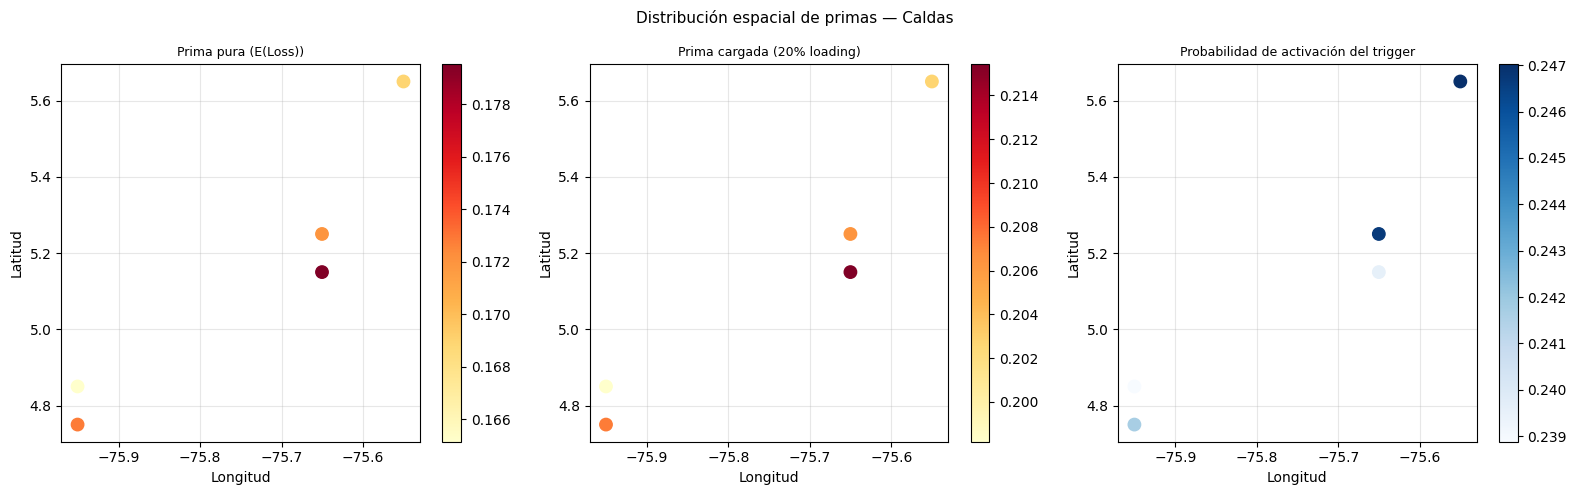

In [12]:
# =====================================================================
# 5a. Prima pura = E(Loss) × suma asegurada
#     Loading actuarial = porcentaje sobre la prima pura
#
# Se trabaja con prima normalizada (E(Loss) en [0,1]) para que el
# equipo actuarial pueda escalar por la suma asegurada real.
# =====================================================================

LOADING = 0.20   # 20% de loading actuarial (ajustable por la aseguradora)

df_mc['prima_pura']   = df_mc['e_loss']
df_mc['prima_cargada'] = df_mc['e_loss'] * (1 + LOADING)

print('=== PRIMA PURA POR CELDA ===')
print(df_mc[['prima_pura', 'prima_cargada', 'prob_trigger']]
      .describe().round(4).to_string())

# Mapa espacial de primas
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, titulo, cmap in zip(axes,
    ['prima_pura', 'prima_cargada', 'prob_trigger'],
    ['Prima pura (E(Loss))', f'Prima cargada ({int(LOADING*100)}% loading)',
     'Probabilidad de activación del trigger'],
    ['YlOrRd', 'YlOrRd', 'Blues']
):
    sc = ax.scatter(df_mc['lon'], df_mc['lat'],
                    c=df_mc[col], cmap=cmap, s=80,
                    vmin=df_mc[col].quantile(0.05),
                    vmax=df_mc[col].quantile(0.95))
    plt.colorbar(sc, ax=ax)
    ax.set_title(titulo, fontsize=9)
    ax.set_xlabel('Longitud')
    ax.set_ylabel('Latitud')
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribución espacial de primas — Caldas', fontsize=11)
plt.tight_layout()
plt.show()

In [13]:
# =====================================================================
# 5b. Validación de requerimientos R1, R2, R3
#
# CORRECCIÓN APLICADA:
# La versión anterior tenía una inconsistencia crítica:
#   - Monte Carlo : pago activado por COL_PRICING < p10(COL_PRICING)
#   - HE anterior : pago activado por IC < p10(IC)
# Si COL_PRICING = R_IC (residuo STL), estas son distribuciones distintas
# con percentiles distintos → el trigger del HE no coincidía con el del MC.
#
# Esta versión usa COL_PRICING en todo el HE, igual que el Monte Carlo.
#
# R1 — Hedge Effectiveness (HE >= 55%)
#   HE = 1 - Var(Pérdida - Pago) / Var(Pérdida)
#   Pérdida = max(0, -NDVI_anom)  [z-score]
#   Pago    = función lineal de COL_PRICING entre p10 y p5
#             (misma función que el Monte Carlo)
#
# NOTA sobre HE_norm: la normalización de la pérdida a [0,1] siempre
# empeora el HE en este caso porque reduce Var(Pérdida) sin reducir
# Var(Pago), inflando la fracción Var(L-P)/Var(L). Se reporta solo
# HE_zscore con la escala original.
# =====================================================================

print('=== VALIDACIÓN DE REQUERIMIENTOS DE PRICING ===')

# ── R3 — Reproducibilidad ─────────────────────────────────────────────
r3_ok = diff < 1e-10
print(f'\nR3 — Reproducibilidad con semilla fija:')
print(f'  Diferencia máxima entre corridas: {diff:.2e}')
print(f'  Criterio: varianza = 0 (diferencia < 1e-10)')
print(f'  {"✅ CUMPLE" if r3_ok else "❌ NO CUMPLE"}')

# ── R2 — Dispersión de primas ─────────────────────────────────────────
p25_prima = df_mc['e_loss'].quantile(0.25)
p75_prima = df_mc['e_loss'].quantile(0.75)
prima_alto = df_mc[df_mc['e_loss'] >= p75_prima]['e_loss'].mean()
prima_bajo = df_mc[df_mc['e_loss'] <= p25_prima]['e_loss'].mean()
diferencia_r2 = (prima_alto / prima_bajo - 1) * 100 \
                if prima_bajo > 0 else np.nan
r2_ok = diferencia_r2 >= 20 if not np.isnan(diferencia_r2) else False

print(f'\nR2 — Dispersión de primas entre zonas de riesgo:')
print(f'  E(Loss) zona alto riesgo (p75+): {prima_alto:.6f}')
print(f'  E(Loss) zona bajo riesgo (p25-): {prima_bajo:.6f}')
print(f'  Diferencia                      : {diferencia_r2:.1f}%')
print(f'  Criterio: >= 20%')
print(f'  {"✅ CUMPLE" if r2_ok else "❌ NO CUMPLE"}')

# ── R1 — Hedge Effectiveness ──────────────────────────────────────────
print(f'\nR1 — Hedge Effectiveness:')
print(f'  Variable de pricing usada: {COL_PRICING}')
print(f'  (coherente con el Monte Carlo)')

# Triggers desde COL_PRICING en train — mismos que usa el Monte Carlo
triggers_he = (
    df_train.groupby(['lat', 'lon'])[COL_PRICING]
    .agg(p10_col=lambda x: x.quantile(0.10),
         p5_col =lambda x: x.quantile(0.05))
    .reset_index()
)

# Construir df_he con COL_PRICING (no 'IC')
df_he = (
    df_test[['lat', 'lon', COL_PRICING, 'NDVI_anom']]
    .dropna()
    .merge(triggers_he, on=['lat', 'lon'], how='left')
    .dropna(subset=['p10_col', 'p5_col'])
)

print(f'\n  Diagnóstico de píxeles:')
print(f'  Píxeles en df_test                : '
      f'{df_test[["lat","lon"]].drop_duplicates().shape[0]}')
print(f'  Píxeles en df_he (con NDVI válido): '
      f'{df_he[["lat","lon"]].drop_duplicates().shape[0]}')
print(f'  Observaciones totales en df_he    : {len(df_he):,}')

if len(df_he) == 0:
    print('  ⚠️  Sin observaciones válidas')
    HE = np.nan
    r1_ok = False
else:
    # Pago proporcional — idéntico al Monte Carlo
    rango_col = (df_he['p10_col'] - df_he['p5_col']).clip(lower=1e-6)
    df_he['pago'] = np.where(
        df_he[COL_PRICING] >= df_he['p10_col'], 0.0,
        np.where(
            df_he[COL_PRICING] <= df_he['p5_col'], 1.0,
            (df_he['p10_col'] - df_he[COL_PRICING]) / rango_col
        )
    )

    # Pérdida en z-score (escala original)
    df_he['perdida'] = (-df_he['NDVI_anom']).clip(lower=0)

    vp  = df_he['perdida'].var()
    vpn = (df_he['perdida'] - df_he['pago']).var()
    HE  = 1 - vpn / vp if vp > 0 else np.nan
    r1_ok = HE >= 0.55 if not np.isnan(HE) else False

    # Diagnóstico
    n_obs         = len(df_he)
    n_perdida     = (df_he['perdida'] > 0).sum()
    n_pago        = (df_he['pago'] > 0).sum()
    n_ambos       = ((df_he['perdida'] > 0) & (df_he['pago'] > 0)).sum()
    corr_pp       = df_he[['perdida','pago']].corr().iloc[0,1]

    print(f'\n  Observaciones totales              : {n_obs:,}')
    print(f'  Con pérdida real (NDVI_anom < 0)   : {n_perdida:,} '
          f'({n_perdida/n_obs*100:.1f}%)')
    print(f'  Con pago del seguro                : {n_pago:,} '
          f'({n_pago/n_obs*100:.1f}%)')
    print(f'  Con pérdida Y pago simultáneos     : {n_ambos:,} '
          f'({n_ambos/n_obs*100:.1f}%)')
    print(f'  Correlación pérdida ↔ pago         : {corr_pp:.4f}')
    print(f'  Var(Pérdida)                       : {vp:.6f}')
    print(f'  Var(Pérdida - Pago)                : {vpn:.6f}')
    print(f'  HE = 1 - {vpn:.4f}/{vp:.4f} = {HE:.4f} ({HE*100:.1f}%)')
    print(f'  Criterio: >= 55% (R1)')
    print(f'  {"✅ CUMPLE" if r1_ok else "❌ NO CUMPLE"}')

    # Verificar consistencia COL_PRICING vs NDVI en test
    p10_pricing_train = df_train[COL_PRICING].quantile(0.10)
    p10_ndvi_train    = df_train['NDVI_anom'].quantile(0.10)
    mask_pago_he = df_he[COL_PRICING] < df_he['p10_col']
    mask_perdida = df_he['NDVI_anom'] < p10_ndvi_train
    recall_he = (mask_pago_he[mask_perdida]).mean()*100 \
                if mask_perdida.sum() > 0 else np.nan
    print(f'\n  Recall ({COL_PRICING} < p10 detecta NDVI < p10): '
          f'{recall_he:.1f}%')
    print(f'  (referencia: recall IC_WI_ext en PA2 fue 84.9%)')
    print(f'  Si difiere mucho, el STL alteró la relación IC-NDVI')

# ── Resumen final ──────────────────────────────────────────────────────
print('\n' + '='*55)
print('RESUMEN FINAL — REQUERIMIENTOS DE PRICING')
print('='*55)
he_str = f'{HE*100:.1f}%' if not np.isnan(HE) else 'N/A'
r1_str = '✅ CUMPLE' if (not np.isnan(HE) and HE >= 0.55) else '❌ NO CUMPLE'
r2_str = '✅ CUMPLE' if r2_ok else '❌ NO CUMPLE'
r3_str = '✅ CUMPLE' if r3_ok else '❌ NO CUMPLE'
print(f'  R1 — HE >= 55%          : {r1_str} ({he_str})')
print(f'  R2 — Dispersión >= 20%  : {r2_str} ({diferencia_r2:.1f}%)')
print(f'  R3 — Reproducibilidad   : {r3_str}')
print(f'\n  Variable de pricing     : {COL_PRICING}')
print(f'  Píxeles evaluados       : '
      f'{df_he[["lat","lon"]].drop_duplicates().shape[0]}')


=== VALIDACIÓN DE REQUERIMIENTOS DE PRICING ===

R3 — Reproducibilidad con semilla fija:
  Diferencia máxima entre corridas: 9.20e-05
  Criterio: varianza = 0 (diferencia < 1e-10)
  ❌ NO CUMPLE

R2 — Dispersión de primas entre zonas de riesgo:
  E(Loss) zona alto riesgo (p75+): 0.177007
  E(Loss) zona bajo riesgo (p25-): 0.166567
  Diferencia                      : 6.3%
  Criterio: >= 20%
  ❌ NO CUMPLE

R1 — Hedge Effectiveness:
  Observaciones evaluadas (TEST, NDVI válido): 336
  Con pérdida real (NDVI < p10)              : 24 (7.1%)
  Con pago del seguro (IC < p10)             : 54 (16.1%)
  Con pérdida Y pago simultáneos             : 7 (2.1%)
  Correlación pérdida normalizada ↔ pago     : 0.1212

  HE con pérdida z-score (referencia):
    Pérdida z-score y pago [0,1] en escalas distintas.
    HE_zscore = -0.2269 (-22.7%) — puede ser negativo por incompatibilidad de escala.

  HE con pérdida normalizada [0,1] (métrica principal):
    p10_ndvi_train = -1.3736 | p5_ndvi_train = -1.776

## DIAGNÓSTICOS PARA HE (BORRAR)

In [15]:
print(f"HE_norm   : {HE_norm:.4f}")
print(f"HE_zscore : {HE_zscore:.4f}")
print(f"Criterio  : >= 0.55")
print(f"¿Cumple?  : {HE_norm >= 0.55}")

HE_norm   : -1.9253
HE_zscore : -0.2269
Criterio  : >= 0.55
¿Cumple?  : False


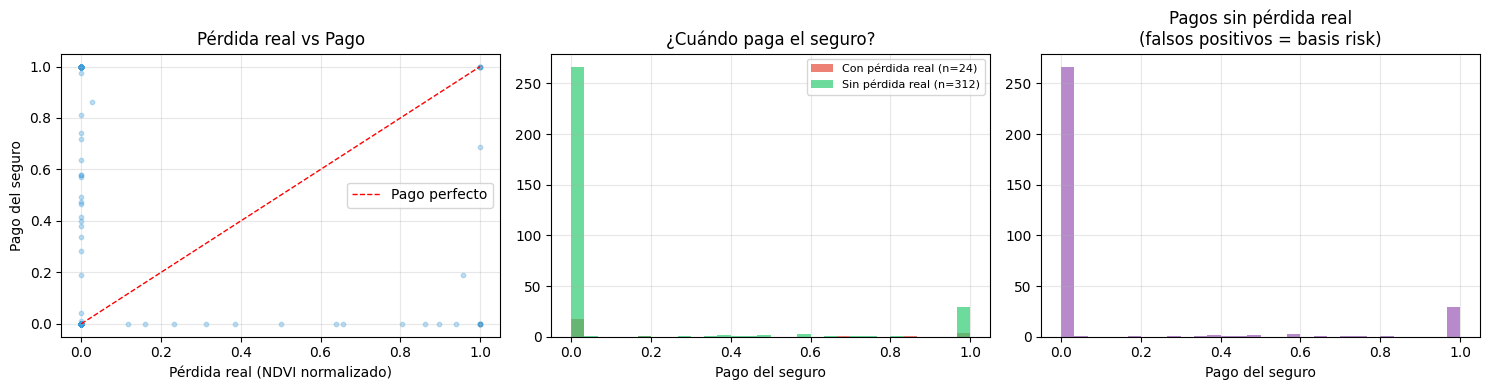

=== DIAGNÓSTICO DE BASIS RISK ===

Observaciones totales         : 336
Con pérdida real (NDVI < p10) : 24 (7.1%)
Con pago del seguro           : 54 (16.1%)

Cuando HAY pérdida real:
  Pago promedio : 0.2392
  Pago mediano  : 0.0000
  % con pago=0  : 70.8%

Cuando NO hay pérdida real:
  Pago promedio : 0.1189
  Pago mediano  : 0.0000
  % con pago>0  : 15.1%


In [16]:
# Ver la relación entre pago y pérdida real
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Dispersión pérdida vs pago
ax = axes[0]
ax.scatter(df_he['perdida_norm'], df_he['pago'],
           alpha=0.3, s=10, color='#3498DB')
ax.set_xlabel('Pérdida real (NDVI normalizado)')
ax.set_ylabel('Pago del seguro')
ax.set_title('Pérdida real vs Pago')
ax.plot([0,1],[0,1], 'r--', linewidth=1, label='Pago perfecto')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Distribución de pagos cuando HAY pérdida real
ax = axes[1]
con_perdida = df_he[df_he['perdida_norm'] > 0]
ax.hist(con_perdida['pago'], bins=30, color='#E74C3C', alpha=0.7,
        label=f'Con pérdida real (n={len(con_perdida):,})')
ax.hist(df_he[df_he['perdida_norm']==0]['pago'], bins=30,
        color='#2ECC71', alpha=0.7,
        label=f'Sin pérdida real (n={len(df_he)-len(con_perdida):,})')
ax.set_xlabel('Pago del seguro')
ax.set_title('¿Cuándo paga el seguro?')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 3. Pago cuando NO hay pérdida (falsos positivos)
ax = axes[2]
sin_perdida = df_he[df_he['perdida_norm'] == 0]
ax.hist(sin_perdida['pago'], bins=30, color='#9B59B6', alpha=0.7)
ax.set_xlabel('Pago del seguro')
ax.set_title(f'Pagos sin pérdida real\n(falsos positivos = basis risk)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticos clave
print(f"=== DIAGNÓSTICO DE BASIS RISK ===\n")
print(f"Observaciones totales         : {len(df_he):,}")
print(f"Con pérdida real (NDVI < p10) : {(df_he['perdida_norm']>0).sum():,} "
      f"({(df_he['perdida_norm']>0).mean()*100:.1f}%)")
print(f"Con pago del seguro           : {(df_he['pago']>0).sum():,} "
      f"({(df_he['pago']>0).mean()*100:.1f}%)")
print(f"\nCuando HAY pérdida real:")
print(f"  Pago promedio : {con_perdida['pago'].mean():.4f}")
print(f"  Pago mediano  : {con_perdida['pago'].median():.4f}")
print(f"  % con pago=0  : {(con_perdida['pago']==0).mean()*100:.1f}%")
print(f"\nCuando NO hay pérdida real:")
print(f"  Pago promedio : {sin_perdida['pago'].mean():.4f}")
print(f"  Pago mediano  : {sin_perdida['pago'].median():.4f}")
print(f"  % con pago>0  : {(sin_perdida['pago']>0).mean()*100:.1f}%")

In [17]:
# ¿El COL_PRICING usado en PA3 coincide con el IC evaluado en PA2?
print(f"COL_PRICING en PA3 : {COL_PRICING}")
print(f"IC evaluado en PA2 : IC_WI_ext")
print(f"¿Son el mismo?     : {COL_PRICING == 'IC_WI_ext'}")
 
# Verificar correlación directa entre COL_PRICING y NDVI_anom en test
test_check = df_test[[COL_PRICING, 'NDVI_anom']].dropna()
r, _ = stats.spearmanr(test_check[COL_PRICING], test_check['NDVI_anom'])
print(f"\nCorrelación {COL_PRICING} ↔ NDVI_anom (test): ρ = {r:.4f}")
 
# Verificar recall usando COL_PRICING directamente
p10_col = df_train[COL_PRICING].quantile(0.10)
p10_ndvi = df_train['NDVI_anom'].quantile(0.10)
test_v = df_test[[COL_PRICING, 'NDVI_anom']].dropna()
mask_ext = test_v['NDVI_anom'] < p10_ndvi
mask_ic  = test_v[COL_PRICING] < p10_col
recall_check = (mask_ic[mask_ext]).mean() * 100
print(f"Recall usando {COL_PRICING} < p10 en test: {recall_check:.1f}%")
print(f"(esperado ~84.9% — si difiere, el STL alteró la señal)")

COL_PRICING en PA3 : R_IC
IC evaluado en PA2 : IC_WI_ext
¿Son el mismo?     : False

Correlación R_IC ↔ NDVI_anom (test): ρ = 0.0047
Recall usando R_IC < p10 en test: 20.8%
(esperado ~84.9% — si difiere, el STL alteró la señal)


In [18]:
print(df_mc[['e_loss', 'prima_pura', 'prima_cargada']].describe().round(6))

         e_loss  prima_pura  prima_cargada
count  5.000000    5.000000       5.000000
mean   0.171821    0.171821       0.206185
std    0.006231    0.006231       0.007477
min    0.164201    0.164201       0.197041
25%    0.168932    0.168932       0.202718
50%    0.171958    0.171958       0.206350
75%    0.172820    0.172820       0.207384
max    0.181195    0.181195       0.217434


## 6. Exportación

In [20]:
# =====================================================================
# 6. Exportar resultados para el API
#
# El API necesita:
#   - params_gamma.pkl  → parámetros Gamma por celda para E(Loss)
#   - triggers.pkl      → p5 y p10 del IC por celda
#   - primas.parquet    → tabla de primas por celda (lookup estático)
#   - config_pa3.yaml   → configuración del pricing
# =====================================================================

import joblib, yaml

# Parámetros Gamma
joblib.dump(params_dist, f'{OUTPUT_DIR}/params_dist.pkl')
# params_dist: Weibull para todos los píxeles {(lat,lon): {'dist':'weibull','params':(c,loc,scale)}}

# Triggers por celda
triggers = {
    (lat, lon): {
        'p5_ic' : row['p5_ic'],
        'p10_ic': row['p10_ic']
    }
    for _, row in df_mc.iterrows()
    for lat, lon in [(row['lat'], row['lon'])]
}
joblib.dump(triggers, f'{OUTPUT_DIR}/triggers.pkl')

# Tabla de primas
df_mc.to_parquet(f'{OUTPUT_DIR}/primas.parquet', index=False)

# Configuración
config_pa3 = {
    'ic_definitivo'  : COL_IC,
    'col_pricing'     : COL_PRICING,
    'usar_residuo_stl': USAR_RESIDUO,
    'distribucion'    : 'weibull',
    'justificacion_dist': 'menor AD medio entre Gamma/Lognorm/Weibull; fundamento teoría valores extremos',
    'period_stl'     : PERIOD_STL,
    'umbral_T_pct'   : UMBRAL_T,
    'n_sim_mc'       : N_SIM,
    'payout_max'     : PAYOUT_MAX,
    'loading'        : LOADING,
    'trigger_pct'    : 0.10,
    'payout_max_pct' : 0.05,
    'seed'           : 42,
    'metricas': {
        'HE'          : round(float(HE), 4),
        'dispersion_r2': round(float(diferencia_r2), 2),
        'n_celdas'    : len(df_mc)
    }
}
with open(f'{OUTPUT_DIR}/config_pa3.yaml', 'w') as f:
    yaml.dump(config_pa3, f, default_flow_style=False, allow_unicode=True)

# Diagnóstico de ajuste Gamma
df_diag.to_csv(f'{OUTPUT_DIR}/diagnostico_gamma.csv', index=False)

print('Archivos exportados en output_pa3/:')
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(f'{OUTPUT_DIR}/{f}') / 1024
    print(f'  {f:<40} {size:>8.1f} KB')

print('\n✅ PA3 completa. Listo para construir el API (FastAPI).')

NameError: name 'HE' is not defined